In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

<Axes: xlabel='theoretical_significance_score', ylabel='mean_empirical_attention'>

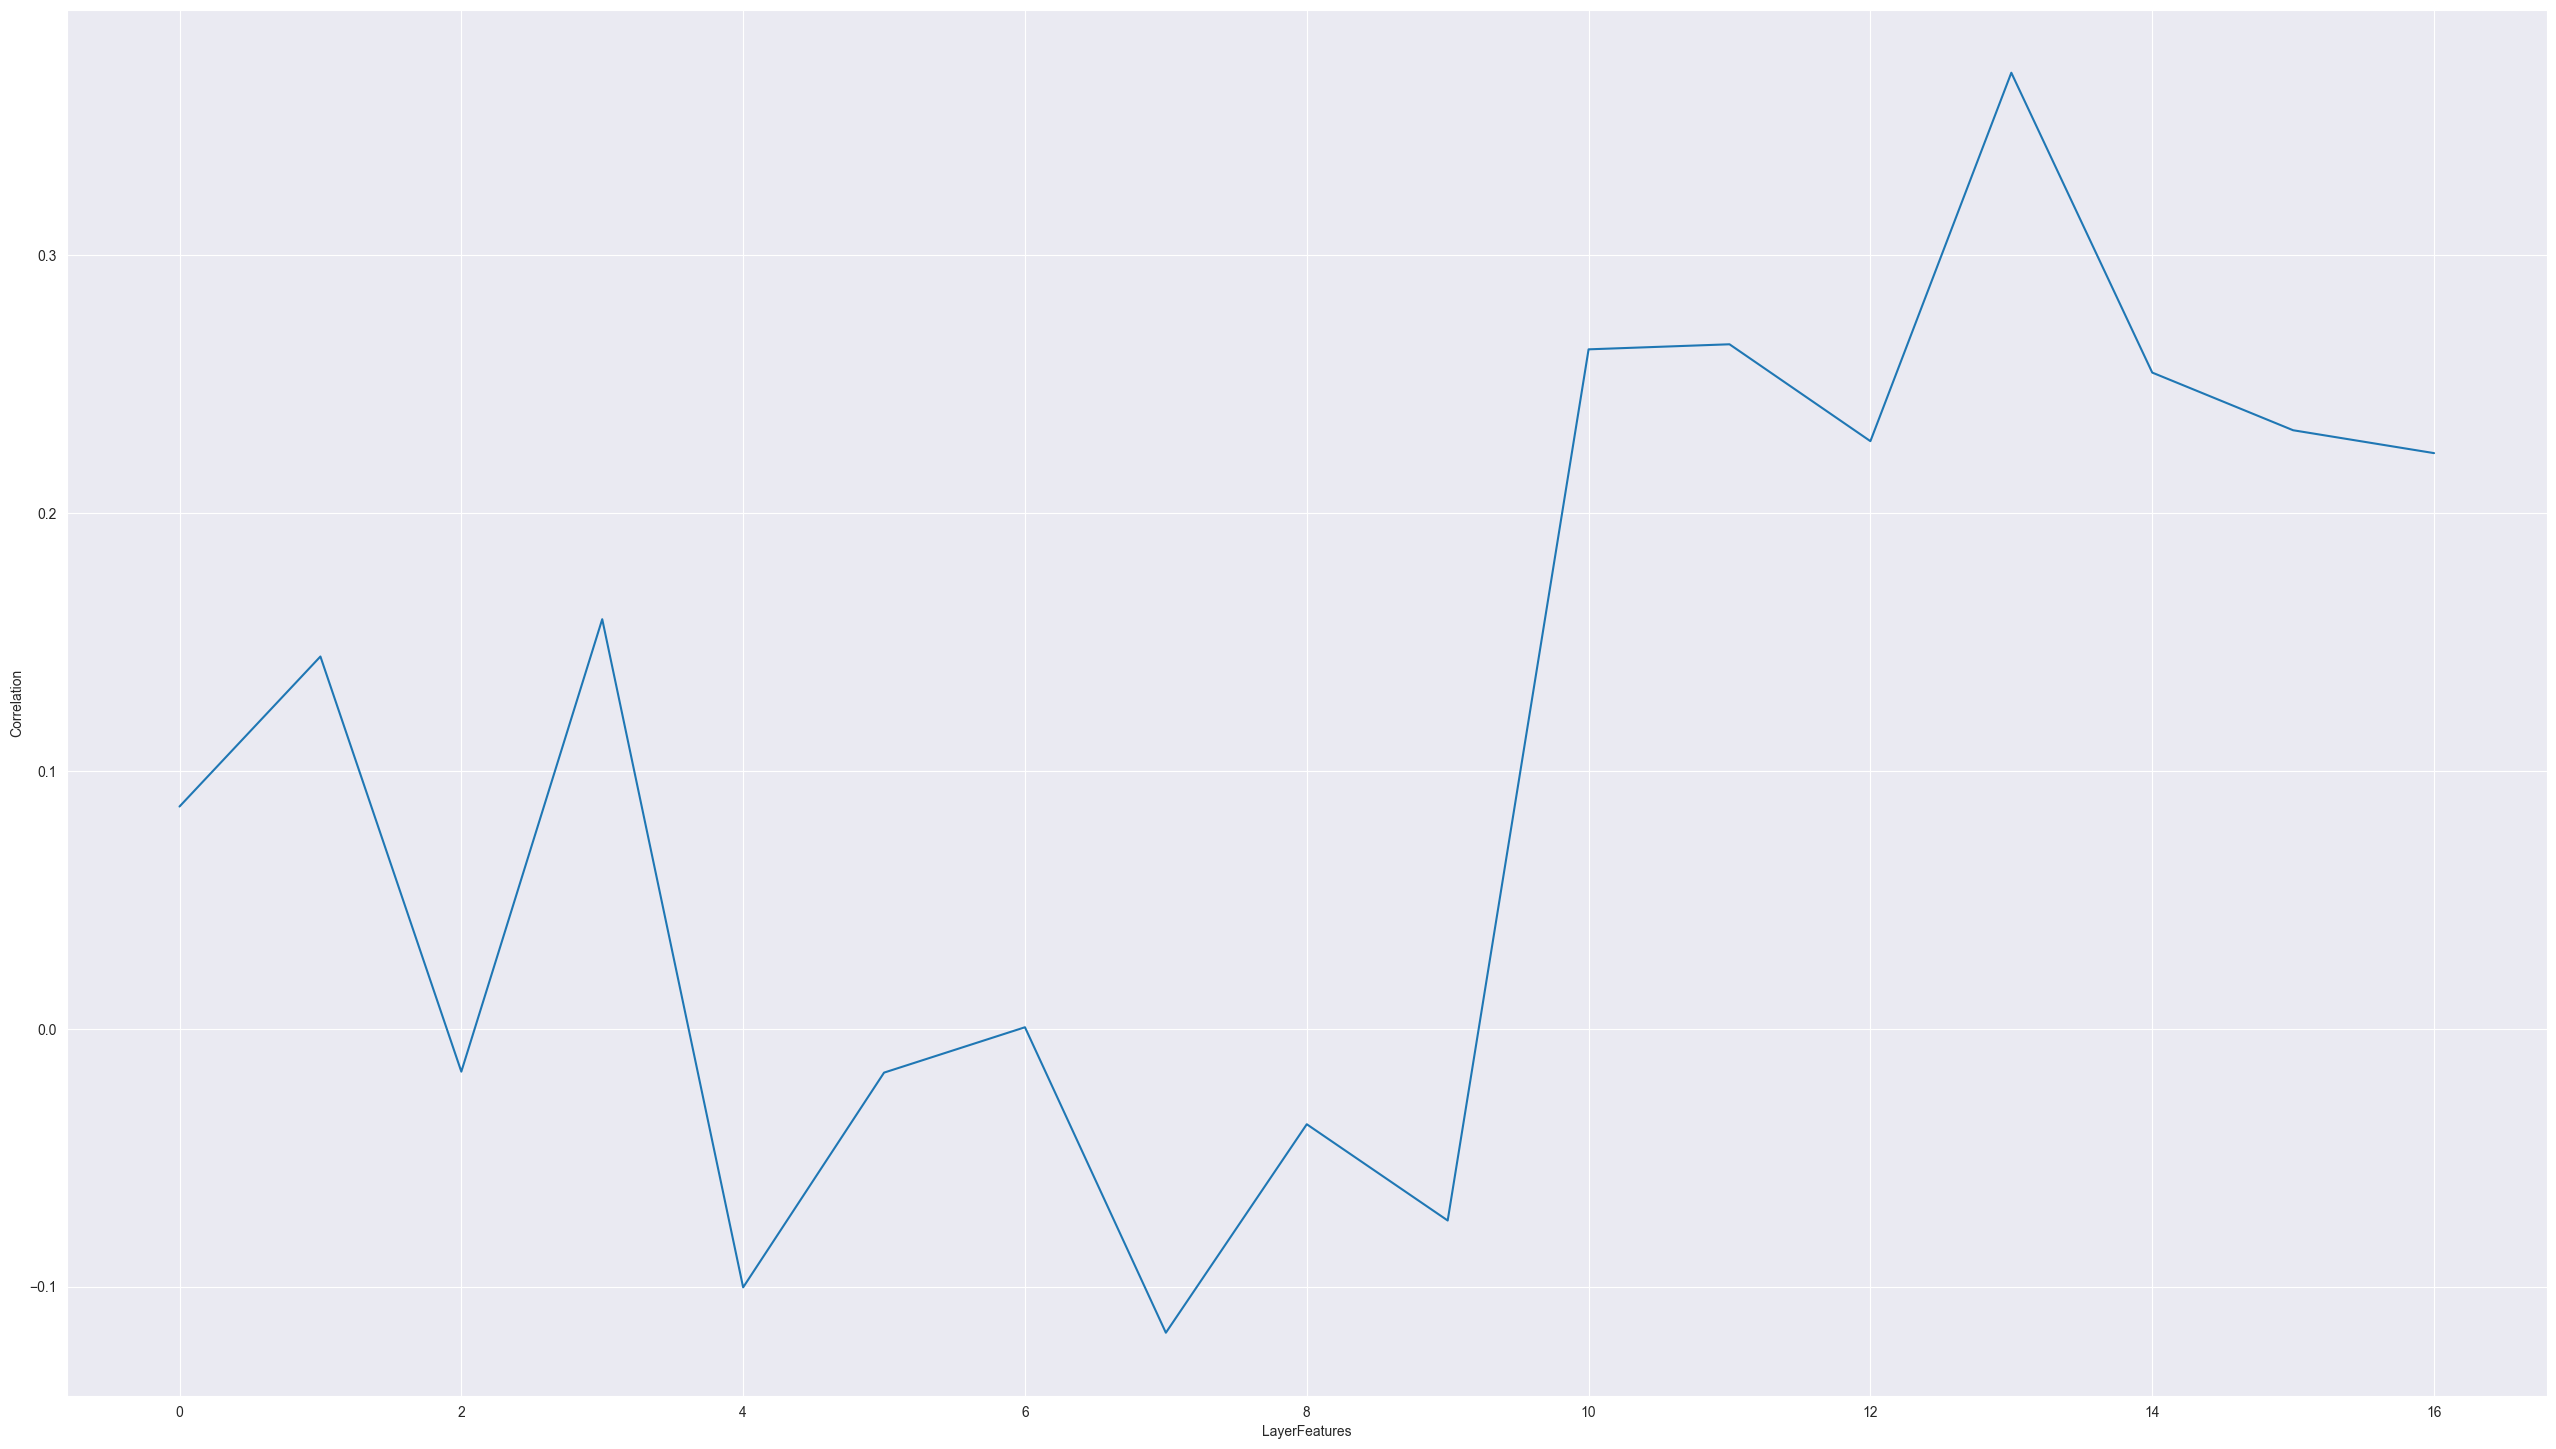

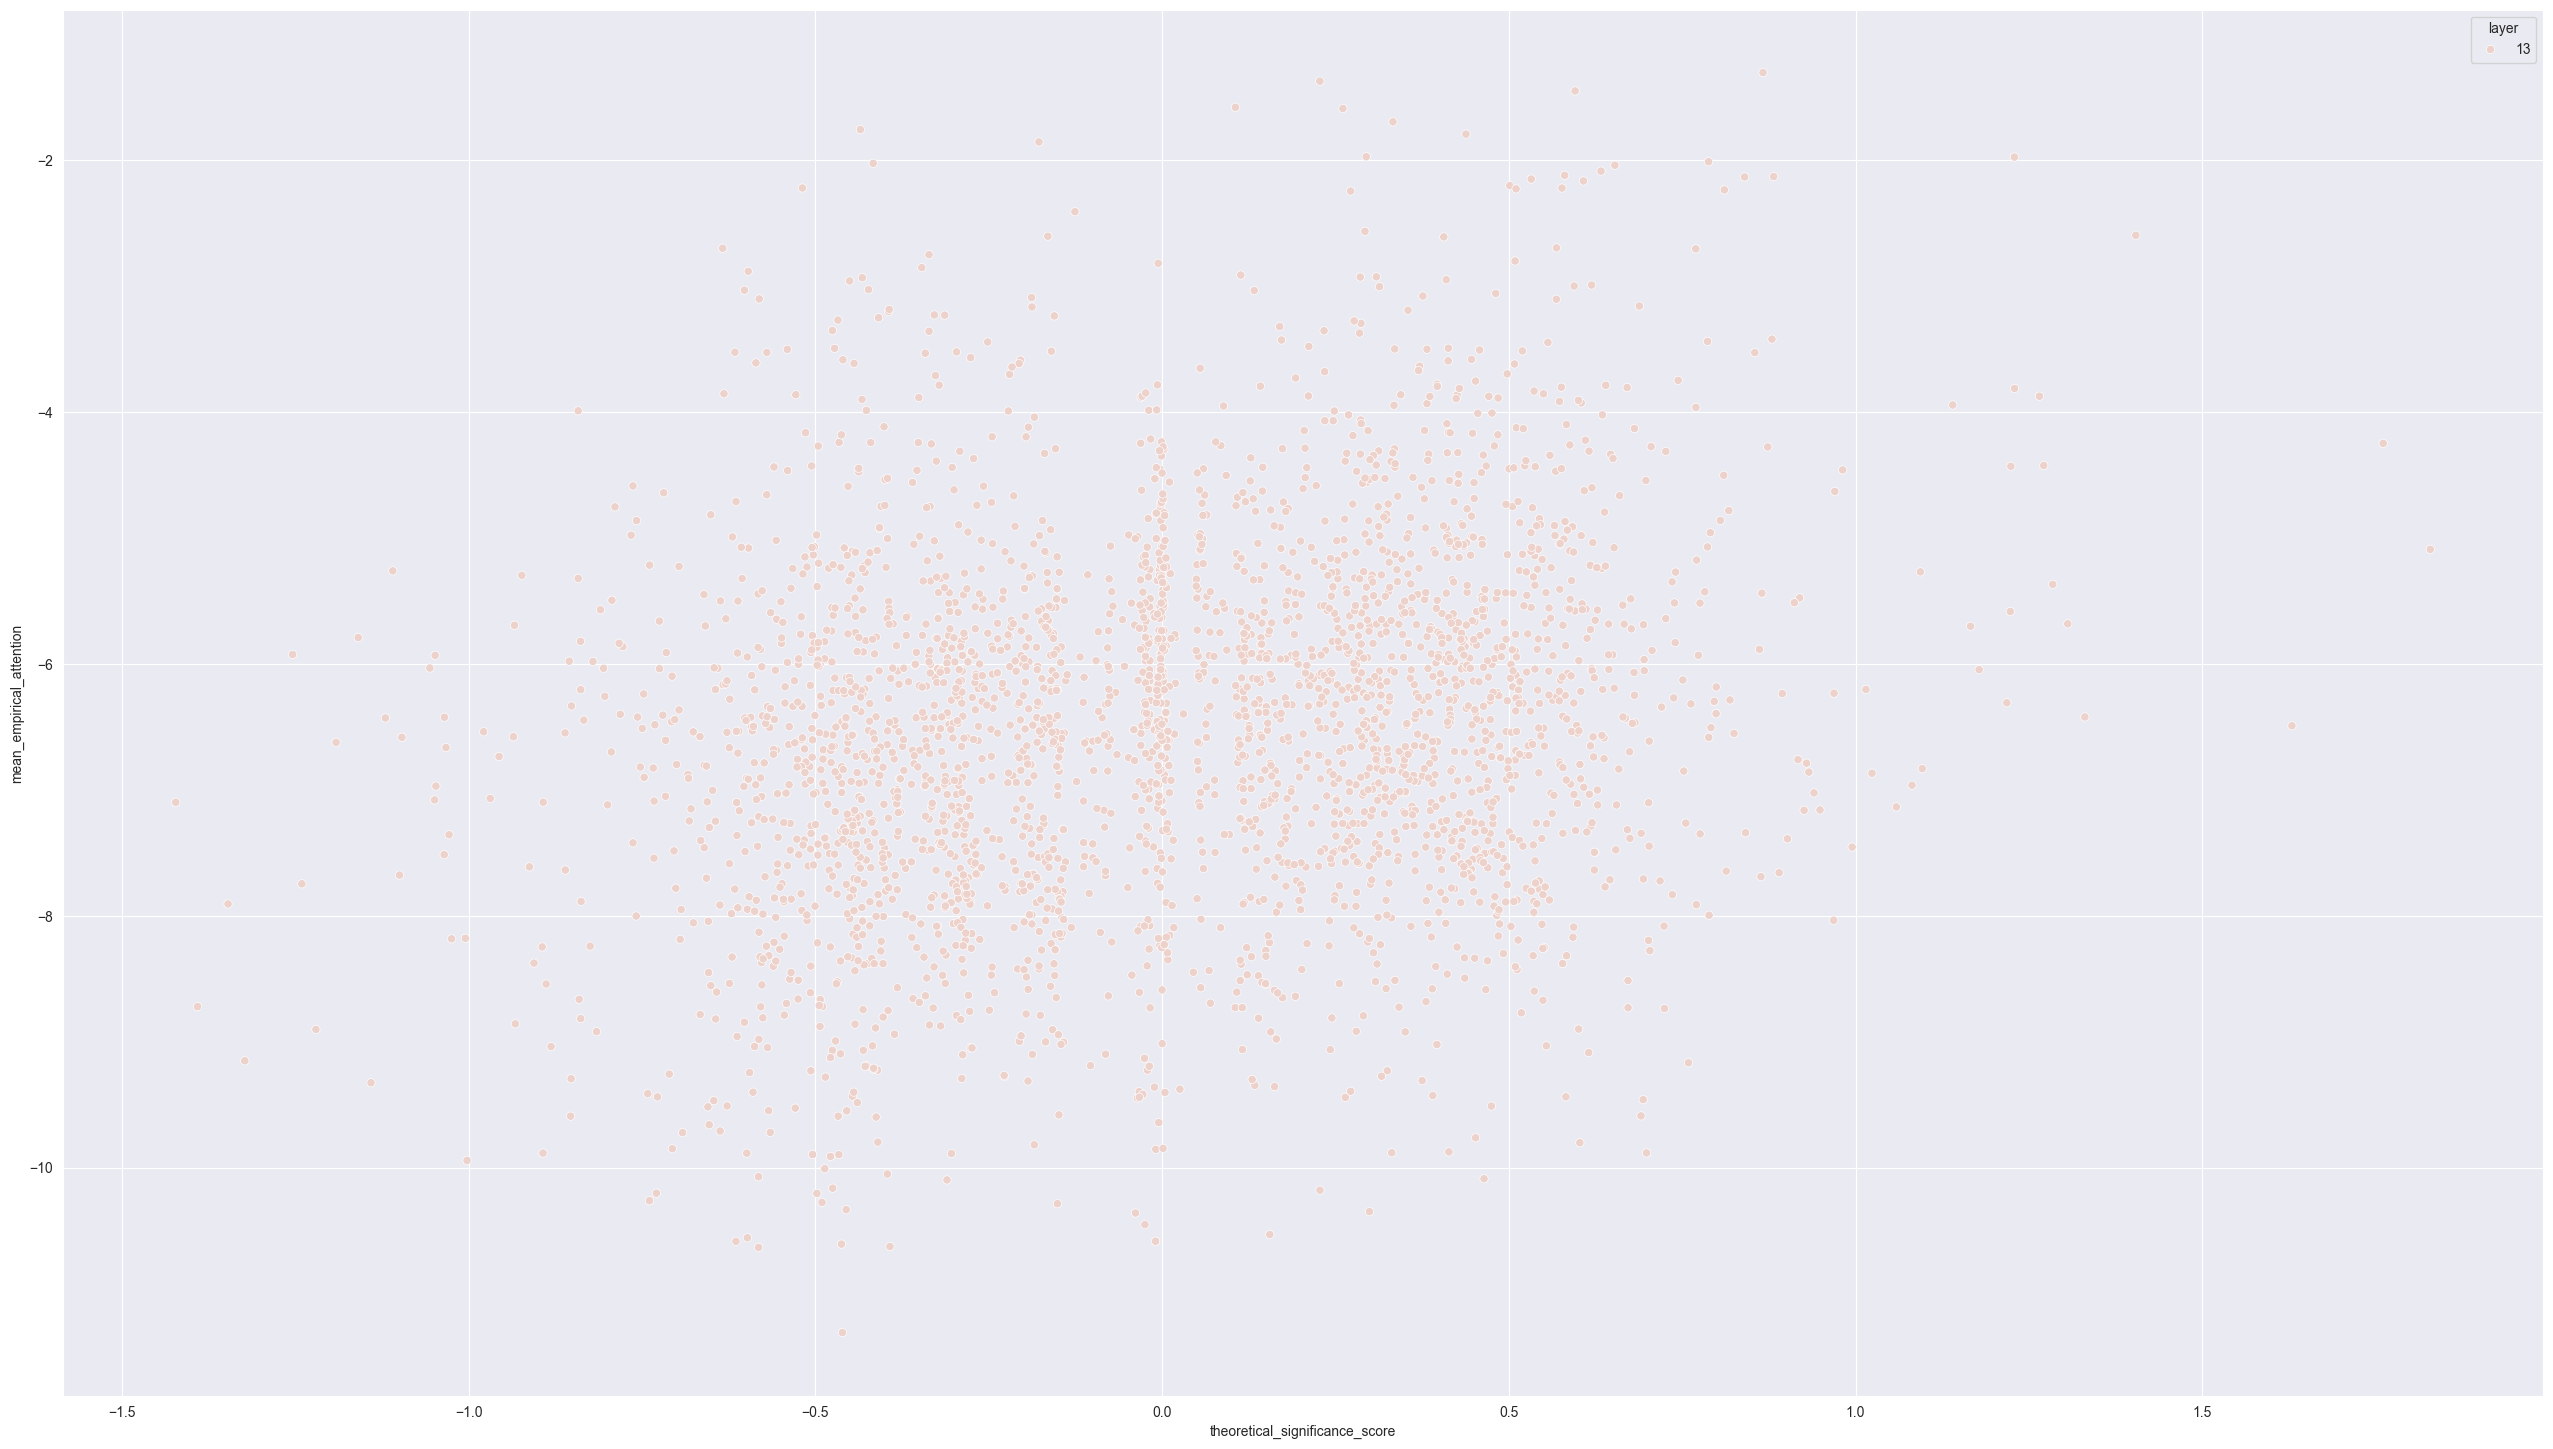

In [3]:
df = pd.read_csv("/home/ahmet/PycharmProjects/CMPE492/results/Gemma/empirical_attention.csv")

df = df[df["no_samples_gathered"] > 100]
df['mean_empirical_attention'] = np.log(df["mean_empirical_attention"])

correlations = []
for layer in range(1, 18):
    layer_data = df[df["layer"] == layer]

    thsc = layer_data["theoretical_significance_score"]

    corr = np.corrcoef(thsc, layer_data["mean_empirical_attention"])[0,1]

    correlations.append(corr)

df_late = df[(df["layer"] >= 10)]
df_late["no_samples_gathered"] /= np.max(df_late["no_samples_gathered"])
df_late["no_samples_gathered"] = np.log(df_late["no_samples_gathered"])


plt.figure(figsize = (32,18))
plt.plot(correlations)
plt.xlabel("LayerFeatures")
plt.ylabel("Correlation")

plt.figure(figsize = (32,18))
sns.scatterplot(df_late[df_late["layer"] == 13], x = "theoretical_significance_score", y = "mean_empirical_attention", hue = "layer")


0.15460480987691957
0.03888616574934918
0.104038358535912
0.14038903225212918
0.19373728773279875
0.2044137234348134
0.12476312917407824
0.16005302436192229
0.0998833249766981
0.1257940567664206
0.17679524341132205
0.17679667507812774
-0.03770458959338319
0.13018294526855562
0.08882771783659195
0.14880242192589016
0.11468345700010636
0.052867587549888496
-0.027088870939972445
-0.02552816053477785
0.07180151474315843
0.0989864723709738
0.2340151573281549
0.13139255816210152
0.07901993616017497
0.1399964467833602
0.20909577175969024
0.2533090607486289
0.2320208213104775
0.22355449435292513
0.2687057674091131
0.20569067894260365
0.2274792344587315
0.333647926242359
0.24659434833937888
0.3682667746035125
0.35345629965635184
0.4252267169516696
0.2872629385635438
0.41445595948259184
0.36708584482141277
0.5068913162549373
0.32297005647159405
0.33428913247080777
0.3271559485383708
0.12572497749473324
0.4427347947725967
0.16839709639277853
0.25672603422081364
0.2639812615300786
0.59400573955216

/home/ahmet/PycharmProjects/CMPE492/.venv/lib/python3.12/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/ahmet/PycharmProjects/CMPE492/.venv/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/ahmet/PycharmProjects/CMPE492/.venv/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/home/ahmet/PycharmProjects/CMPE492/.venv/lib/python3.12/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/ahmet/PycharmProjects/CMPE492/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


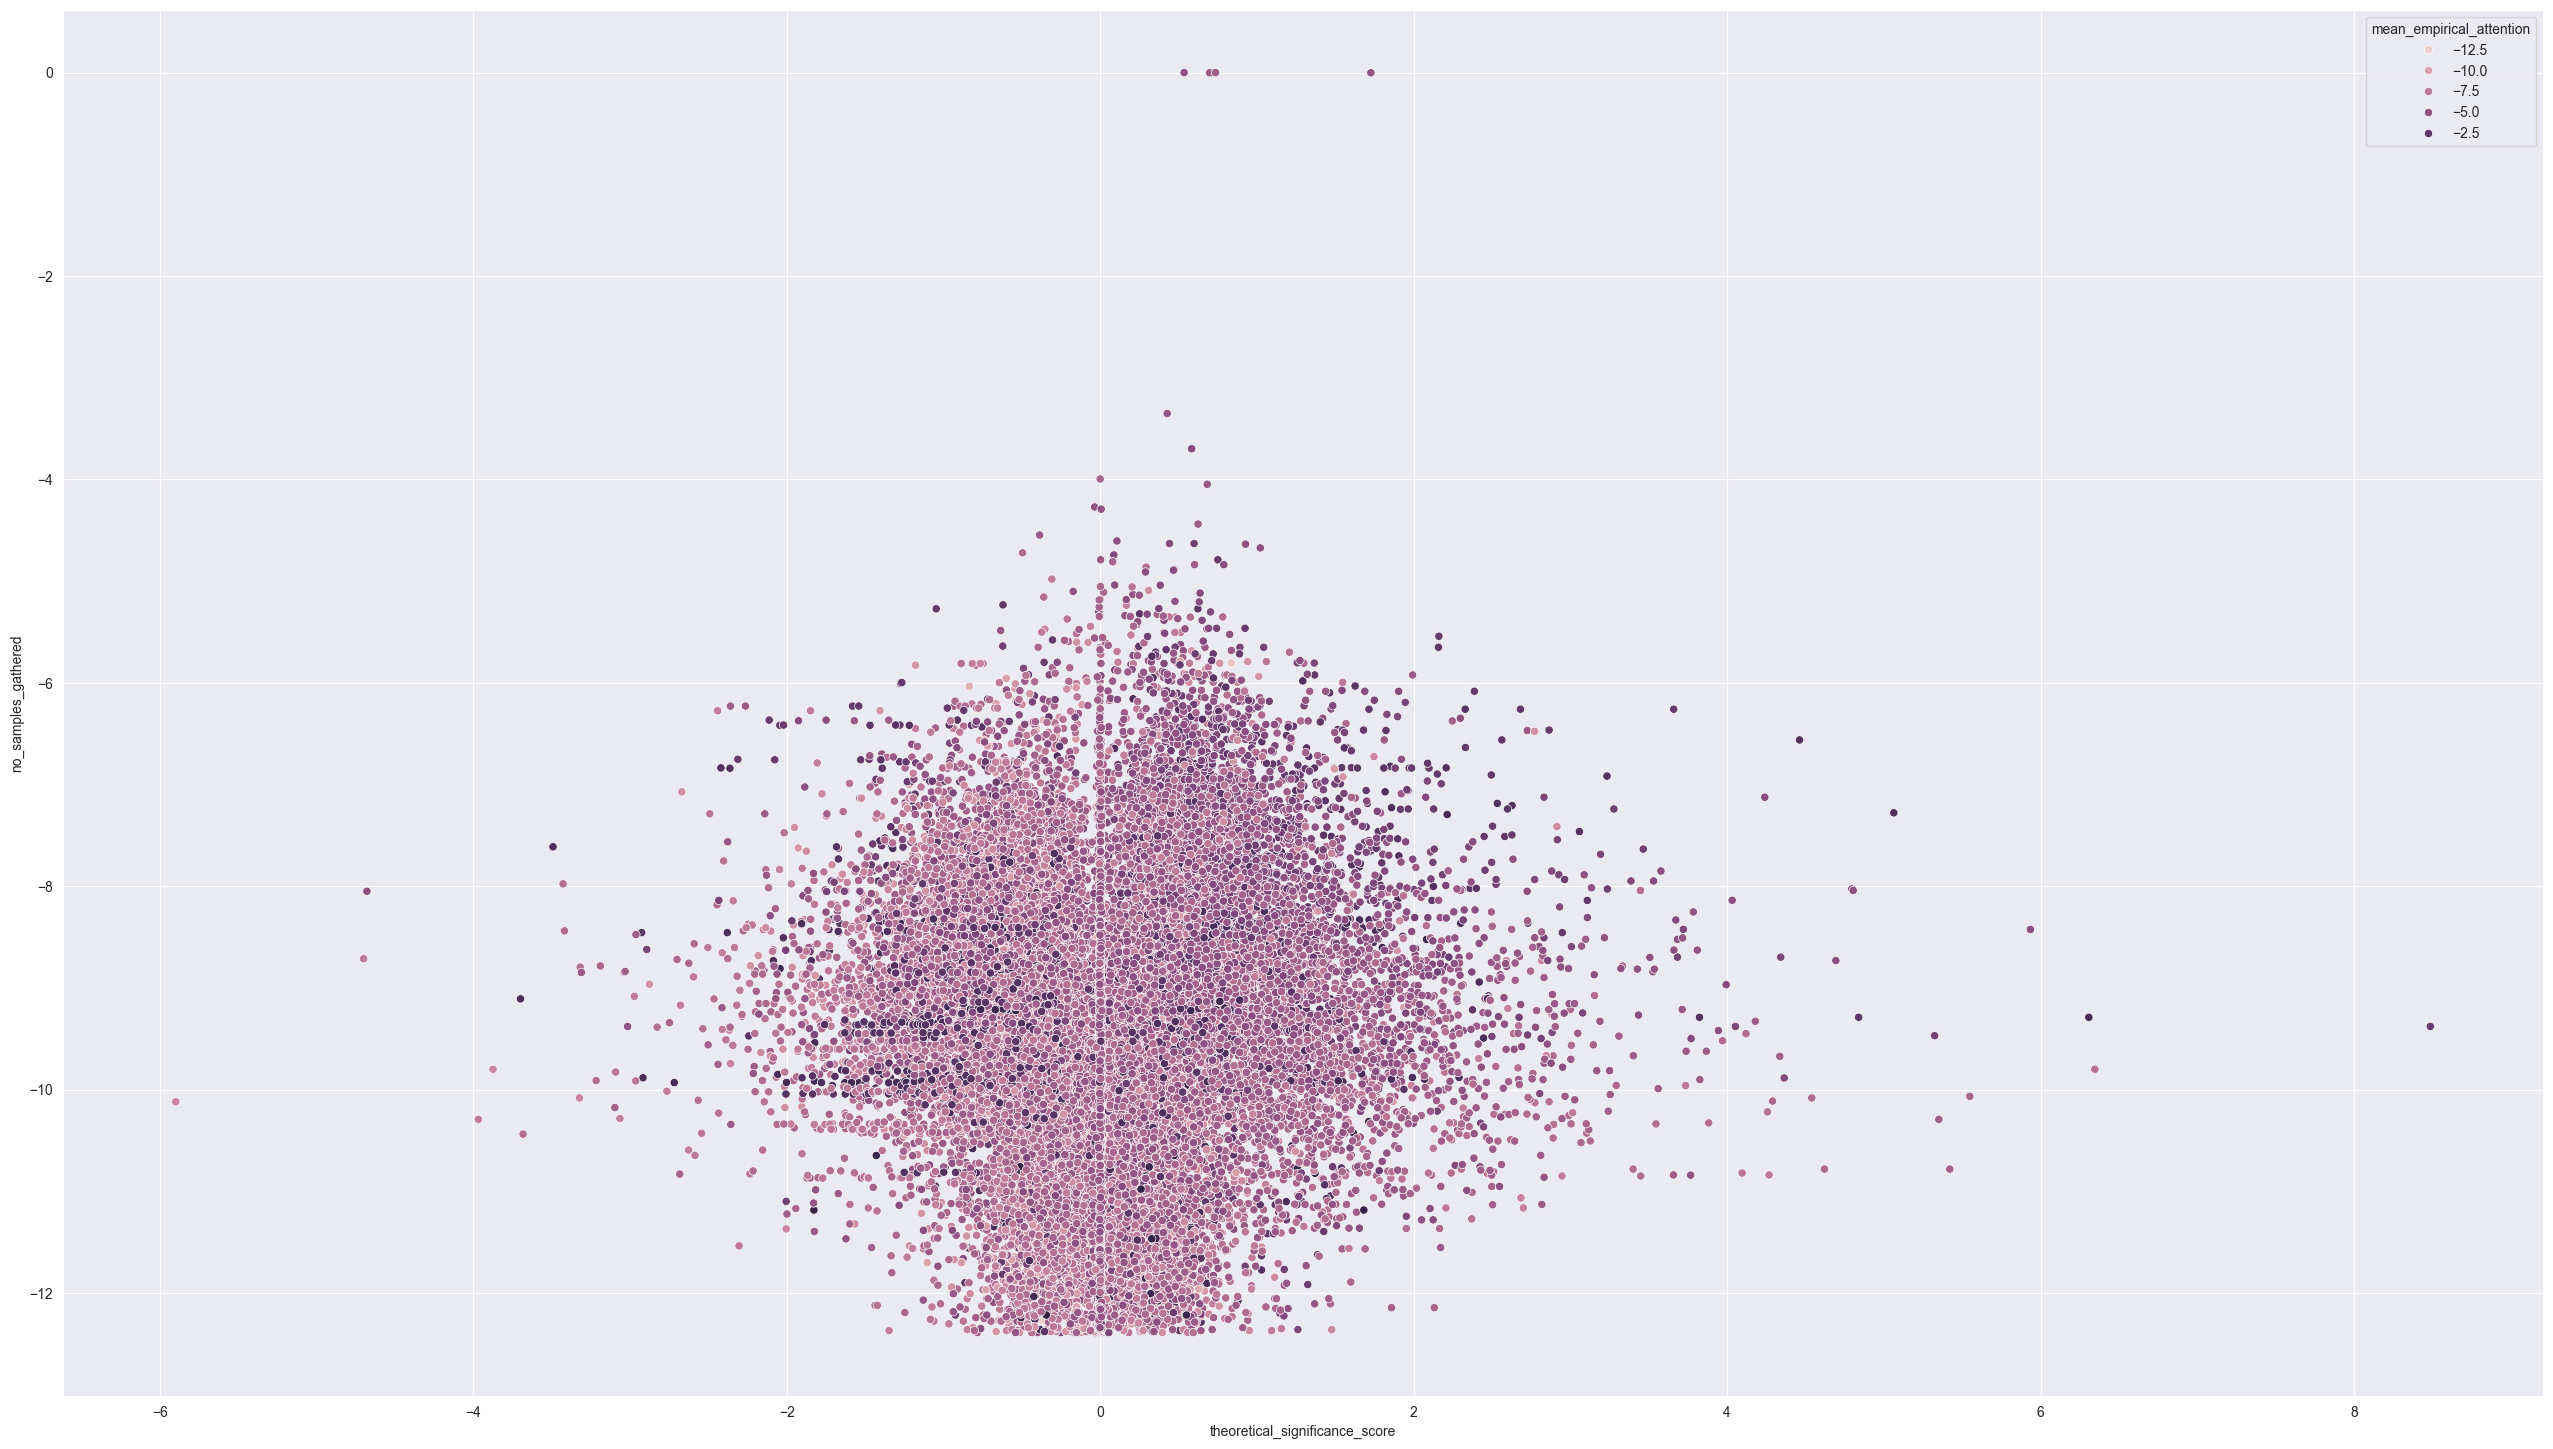

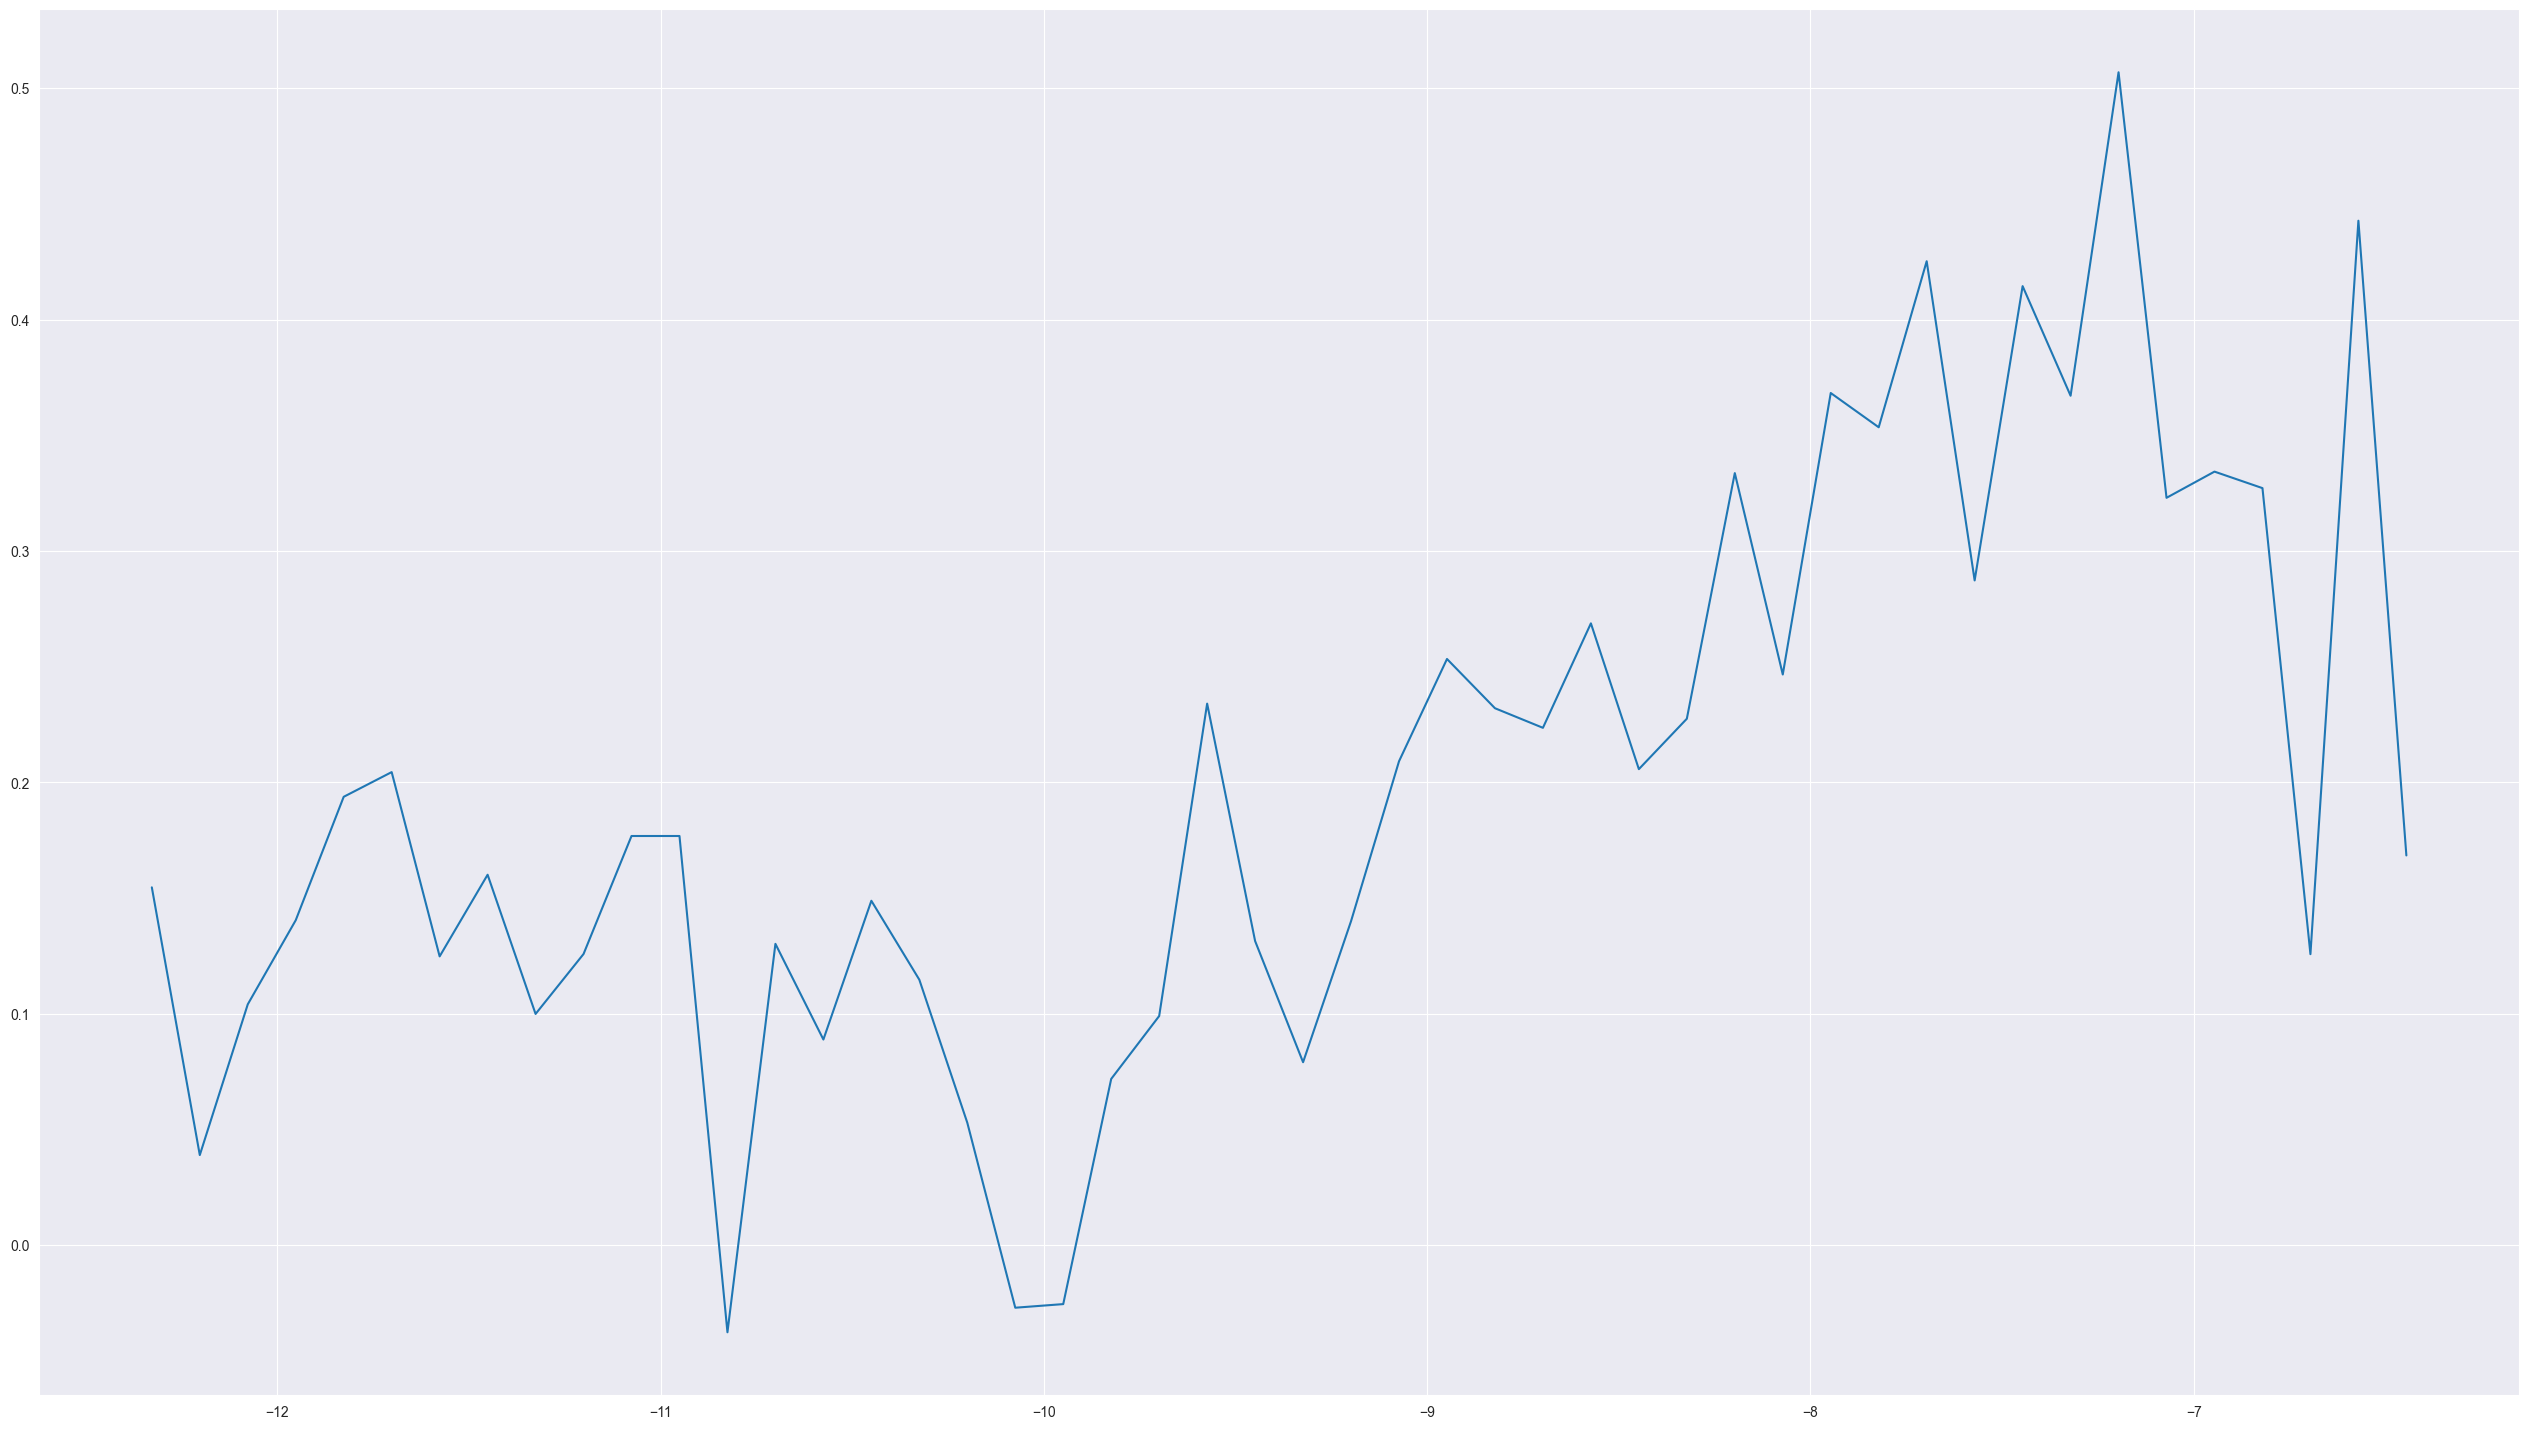

In [44]:

bounds = np.linspace(np.min(df_late["no_samples_gathered"]), np.max(df_late["no_samples_gathered"]), 100)
correlations = []
ranges = []
samples = []

for i in range(1, len(bounds)):
    df_scarcity_filter = (df_late["no_samples_gathered"] >= bounds[i-1]) & (df_late["no_samples_gathered"] < bounds[i])
    df_scarcity = df_late[df_scarcity_filter]

    corr = np.corrcoef(df_scarcity["theoretical_significance_score"], df_scarcity["mean_empirical_attention"])[0,1]
    print(corr)

    correlations.append(corr)
    ranges.append((bounds[i] + bounds[i-1])/2)
    samples.append(len(df_scarcity))

correlations = np.array(correlations)
ranges = np.array(ranges)
samples = np.array(samples)

plt.figure(figsize = (32,18))
sns.scatterplot(df_late, x = "theoretical_significance_score", y= "no_samples_gathered",hue = "mean_empirical_attention")

plt.figure(figsize = (32,18))
plt.plot(ranges[samples > 100], correlations[samples > 100])